In [38]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [39]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data")

print("Path to dataset files:", path)

df = pd.read_csv(os.path.join(path, "AB_NYC_2019.csv"))
df.head()

Path to dataset files: C:\Users\itsmo\.cache\kagglehub\datasets\dgomonov\new-york-city-airbnb-open-data\versions\3


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [40]:
print('describe:->')
print(df.describe(include='all'))
print()
print('--------------------------------------------------------------------------------------------------')

print('datatypes:-> ')
print(df.info())
print()
print('---------------------------------------------------------------------------------------------------')


print('shape:-> ')
print(df.shape)
print()
print('---------------------------------------------------------------------------------------------------')

print('null count:-> ')
print(df.isnull().sum())
print()
print('---------------------------------------------------------------------------------------------------')

print('duplicate count:-> ')
print(df.duplicated().sum())
print()
print('---------------------------------------------------------------------------------------------------')

describe:->
                  id            name       host_id host_name  \
count   4.889500e+04           48879  4.889500e+04     48874   
unique           NaN           47905           NaN     11452   
top              NaN  Hillside Hotel           NaN   Michael   
freq             NaN              18           NaN       417   
mean    1.901714e+07             NaN  6.762001e+07       NaN   
std     1.098311e+07             NaN  7.861097e+07       NaN   
min     2.539000e+03             NaN  2.438000e+03       NaN   
25%     9.471945e+06             NaN  7.822033e+06       NaN   
50%     1.967728e+07             NaN  3.079382e+07       NaN   
75%     2.915218e+07             NaN  1.074344e+08       NaN   
max     3.648724e+07             NaN  2.743213e+08       NaN   

       neighbourhood_group neighbourhood      latitude     longitude  \
count                48895         48895  48895.000000  48895.000000   
unique                   5           221           NaN           NaN   
top

# <font color='violet'>Exploratory data analysis </font>

In [7]:
#missing values 
missing = df.isnull().sum()
missing[missing > 0]

name                    16
host_name               21
last_review          10052
reviews_per_month    10052
dtype: int64

<Axes: xlabel='room_type', ylabel='count'>

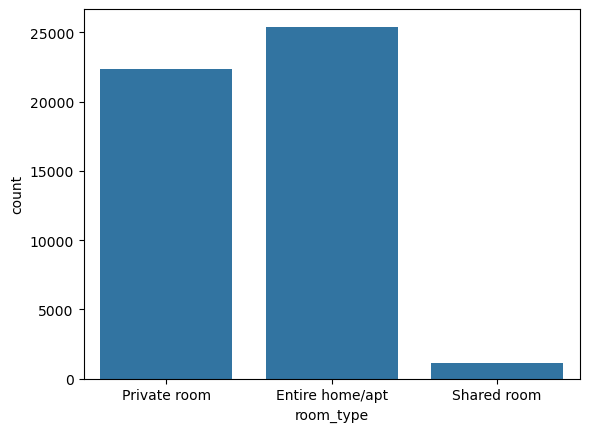

In [13]:
#room type 
df['room_type'].value_counts()

sns.countplot(x='room_type',data=df)

In [9]:
#there is class imbalance :-> shared room

array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'minimum_nights'}>],
       [<Axes: title={'center': 'number_of_reviews'}>,
        <Axes: title={'center': 'reviews_per_month'}>],
       [<Axes: title={'center': 'calculated_host_listings_count'}>,
        <Axes: title={'center': 'availability_365'}>]], dtype=object)

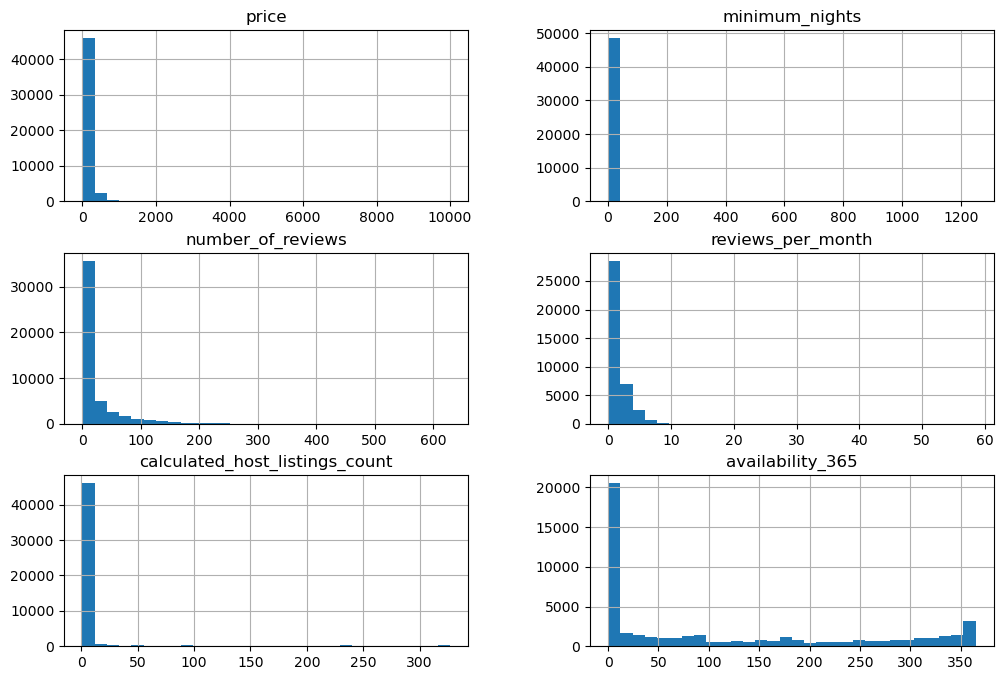

In [14]:
#numerical columns 
numerical_cols = ["price", "minimum_nights", "number_of_reviews",
                 "reviews_per_month", "calculated_host_listings_count",
                 "availability_365"]
df[numerical_cols].hist(bins=30, figsize=(12, 8))

<Axes: xlabel='neighbourhood_group', ylabel='count'>

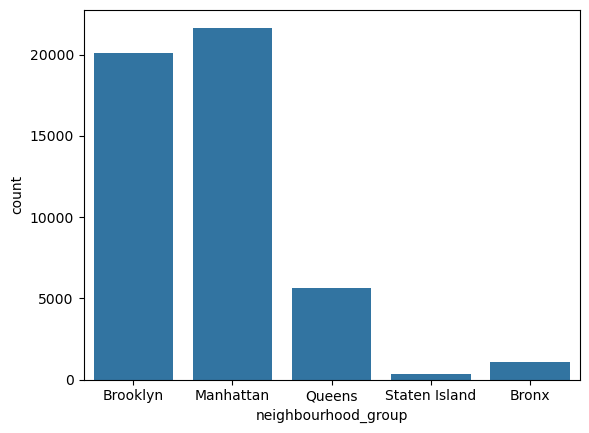

In [15]:
#neighbourhood_group
sns.countplot(data=df, x='neighbourhood_group')

<Axes: xlabel='room_type', ylabel='price'>

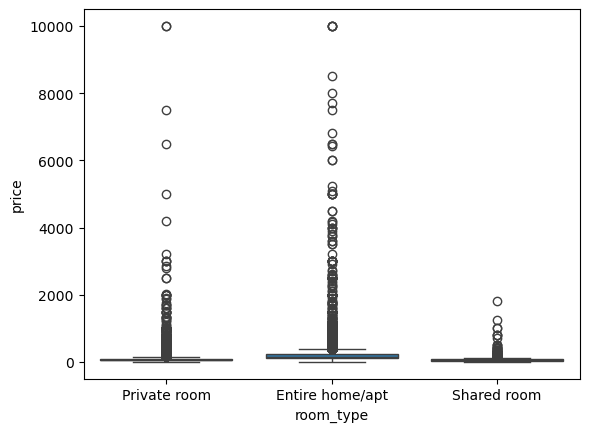

In [16]:
#room type vs price 
sns.boxplot(x='room_type', y='price', data=df)

<Axes: >

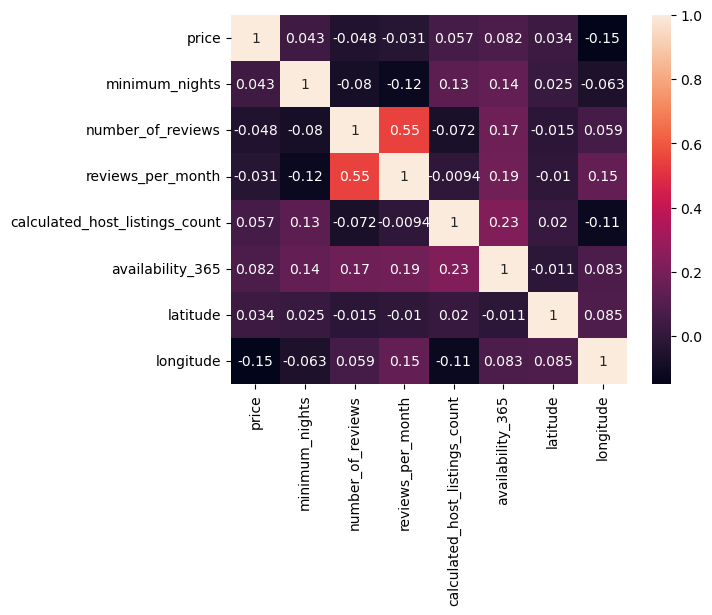

In [17]:
#correlation heatmap 
corr = df[numerical_cols + ['latitude', 'longitude']].corr()
sns.heatmap(corr,annot=True
            )

# <font color='violet'>Data Cleaning</font>

In [41]:
#1. Drop Colunmns that dont help us.
df_clean = df.drop(columns=['id', 'name', 'host_id', 'host_name', 'last_review'])

#2. No reviews yet -> 0 reviews per month, not missing
df_clean['reviews_per_month'] = df_clean['reviews_per_month'].fillna(0)

In [42]:
#3. Cap Extreme outliers instead of deleting rows.

price_cap  = df_clean['price'].quantile(0.99)
nights_cap = df_clean['minimum_nights'].quantile(0.99)

df_clean['price'] = df_clean['price'].clip(upper=price_cap)
df_clean['minimum_nights'] = df_clean['minimum_nights'].clip(upper=nights_cap)

In [43]:
#selection features and target 
X = df_clean.drop(columns=['room_type'])
y = df_clean['room_type']

# <font color='violet'>Train Test Split</font>

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42, stratify=y)
#we did stratify=y because we want to maintain the proportion of data in training and testing 


# <font color='violet'>Preprocessing</font>

In [45]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer

In [46]:
numerical_cols = ["latitude","longitude","price", "minimum_nights", "number_of_reviews",
                 "reviews_per_month", "calculated_host_listings_count",
                 "availability_365"]

categorical_cols = ['neighbourhood_group', 'neighbourhood']

#1. Pipeline -> for Numeric Columns
numeric_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy="median")),
    ('scale', StandardScaler())
])


#2. Pipeline -> for Categorical Columns
categorical_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy="most_frequent")),
    ('encode', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ("numerical", numeric_pipeline, numerical_cols),
    ("categorical", categorical_pipeline, categorical_cols )
])

preprocessor

,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [47]:
df_clean['room_type'].unique()

array(['Private room', 'Entire home/apt', 'Shared room'], dtype=object)

# <font color='violet'>Model Training and class balancing </font>

In [48]:
import warnings
warnings.filterwarnings('ignore')

In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

In [50]:
# class_weight="Balanced" tells the model to pay more attention to the minority class
# or rare class (Shared Room)
# but the problem is GradintBossting doesnt support class weight so we left it as it is.

models = {
    "Logistic Regression" : LogisticRegression(class_weight="balanced",random_state=42),
    "Decision Tree"       : DecisionTreeClassifier(class_weight="balanced",random_state=42),
    "Random Forest"       : RandomForestClassifier(class_weight="balanced", random_state=42),
    "Gradient Boosting"   : GradientBoostingClassifier(random_state=42),
}

for name, model in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", model)])

    # Accuracy alone can be misleading on imbalanced classes, so we use macro f1
    # both: plain accuracy and macro f1 (which treats every class equally)

    accuracy = cross_val_score(pipe, X_train, y_train,cv=3,scoring="accuracy")
    macrof1 = cross_val_score(pipe, X_train, y_train,cv=3,scoring="f1_macro")

    print(f"{name} -> Accuracy: {accuracy.mean():.3f} , F1: {macrof1.mean():.3f}")

Logistic Regression -> Accuracy: 0.659 , F1: 0.522
Decision Tree -> Accuracy: 0.782 , F1: 0.647
Random Forest -> Accuracy: 0.851 , F1: 0.715
Gradient Boosting -> Accuracy: 0.850 , F1: 0.705


In [51]:
#we will chose rRandomForestClassifier

# <font color='violet'>HyperParamter Tunning</font>

In [52]:
from sklearn.model_selection import RandomizedSearchCV

best_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier",   RandomForestClassifier(class_weight='balanced'))
])

param_distribution = {
    "classifier__n_estimators" : [100,200,150,300],
    "classifier__max_depth": [8, 12, 15, 20, None],
    "classifier__min_samples_split": [2, 5, 10],
}

search = RandomizedSearchCV(
    estimator=best_pipeline,
    param_distributions=param_distribution,
    n_iter=10,
    cv=3,
    scoring="f1_macro",
    random_state=42
    )

search.fit(X_train, y_train)

,estimator,Pipeline(step...'balanced'))])
,param_distributions,"{'classifier__max_depth': [8, 12, ...], 'classifier__min_samples_split': [2, 5, ...], 'classifier__n_estimators': [100, 200, ...]}"
,n_iter,10
,scoring,'f1_macro'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [53]:
print("Best Parameters: ", search.best_params_)
print("Best CV Macro-F1: ", search.best_score_)

Best Parameters:  {'classifier__n_estimators': 200, 'classifier__min_samples_split': 10, 'classifier__max_depth': None}
Best CV Macro-F1:  0.733341995946763


In [56]:
#model evaluation
from sklearn.metrics import accuracy_score, confusion_matrix,f1_score
best_pipeline = search.best_estimator_

y_pred = best_pipeline.predict(X_test)

print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}")
print(f"F1 Score: {f1_score(y_test, y_pred, average="macro")}")

Accuracy Score: 0.8560361923648984
F1 Score: 0.7371877846976324


<Axes: >

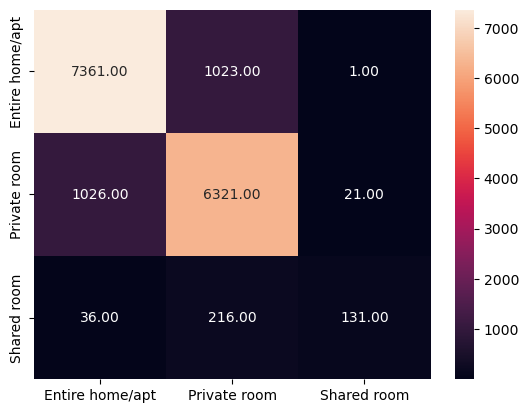

In [57]:
sns.heatmap(confusion_matrix(y_test,y_pred), annot=True, fmt=".2f",
            xticklabels=best_pipeline.classes_, yticklabels=best_pipeline.classes_)

In [58]:
import joblib

joblib.dump(best_pipeline, "Model_Pipeline.pkl",compress=3)

['Model_Pipeline.pkl']